In [1]:
import geopandas as gpd
from pathlib import Path
import yaml

In [2]:
# ---- config ----
yaml_file = "US_states.yaml"
src_geojson = "geoBoundaries-USA-ADM1_simplified.geojson"
dst_geojson = "USA_states.geojson"
name_col = "shapeName"

In [3]:
# ---- functions ----
def read_states(yaml_path: str | Path, prefix: str = "USA|") -> set[str]:
    p = Path(yaml_path)
    with p.open("r", encoding="utf-8") as f:
        data = yaml.safe_load(f)
    vals = next(iter(data[0].values()))
    return {
        s.split("|", 1)[1].strip()
        for s in vals
        if isinstance(s, str) and s.startswith(prefix)
    }


def read_gdf(path: str | Path) -> gpd.GeoDataFrame:
    return gpd.read_file(Path(path))


def filter_by_names(
    gdf: gpd.GeoDataFrame,
    names: set[str],
    col: str = "shapeName",
) -> gpd.GeoDataFrame:
    return gdf[gdf[col].isin(names)].copy()


def write_geojson(gdf: gpd.GeoDataFrame, path: str | Path):
    gdf.to_file(Path(path), driver="GeoJSON")


def plot_gdf(gdf: gpd.GeoDataFrame):
    ax = gdf.plot(figsize=(20, 8))
    ax.set_axis_off()

YAML names (51):
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

Filtered result (51):
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Misso

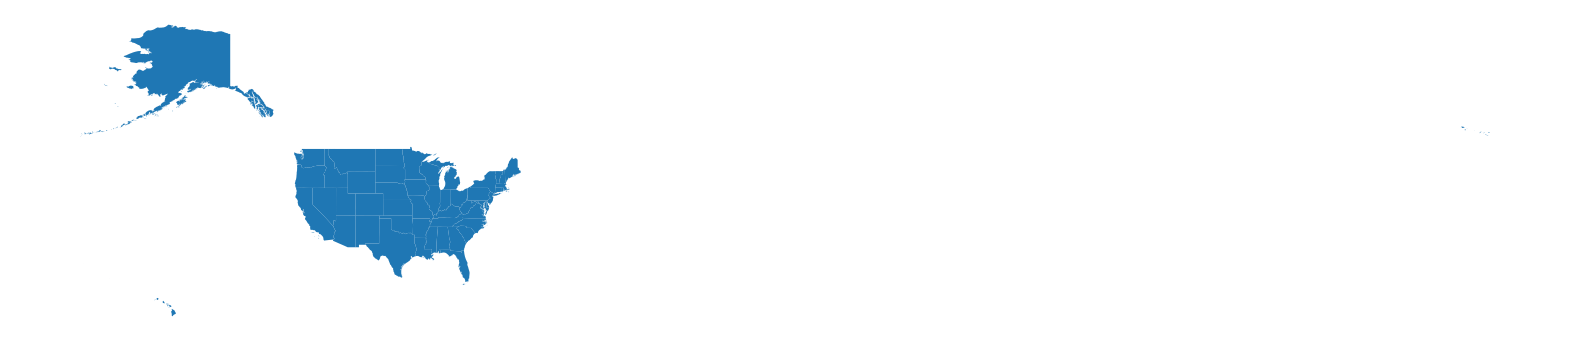

In [4]:
names = read_states(yaml_file)
gdf_all = read_gdf(src_geojson)
gdf_sel = filter_by_names(gdf_all, names, col=name_col)

print(f"YAML names ({len(names)}):")
print(sorted(names))
print()

print(f"Filtered result ({len(gdf_sel)}):")
print(sorted(gdf_sel[name_col].unique()))
print()

missing = names - set(gdf_sel[name_col])
print(f"LEFT OUT (in YAML but not in filtered result) ({len(missing)}):")
print(sorted(missing))
print()

# Write and plot
write_geojson(gdf_sel, dst_geojson)
plot_gdf(gdf_sel)